In [69]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:
font="Times New Roman"
family="serif"
mathfont="stix"

plt.rcParams['axes.labelsize'] = 'xx-large'
plt.rcParams["font.family"] = family
plt.rcParams["font.serif"] = [font]
plt.rcParams["mathtext.fontset"] = mathfont
for tick in ['xtick', 'ytick']:
    plt.rcParams[f'{tick}.labelsize'] = 'xx-large'
    plt.rcParams[f'{tick}.minor.pad'] = 3.9
    plt.rcParams[f'{tick}.minor.size'] = 2.5
    plt.rcParams[f'{tick}.minor.width'] = 1.  # 0.6
    plt.rcParams[f'{tick}.major.pad'] = 4.0
    plt.rcParams[f'{tick}.major.size'] = 4.0
    plt.rcParams[f'{tick}.major.width'] = 1.2  # 0.8

Setting the phyiscal constants

In [73]:
c = 299792458         # Speed of light (m/s)
e = 1.60217663e-19    # Electron charge (C)
me = 9.1093837e-31    # Electron mass (kg)
eps0 = 8.85418782e-12 # Vacuum permittivity (F/m)

# Sodium D-lines transition data
omega01 = 3.193952e15 # D1 Resonance frequency (rad/s)
omega02 = 3.197191e15 # D2 Resonance frequency (rad/s)
f1 = 0.318            # D1 Oscillator strength
f2 = 0.641            # D2 Oscillator strength

# Damping terms (Natural vs. Doppler Broadened)
gamma1_nat = 6.1353e7 # Natural damping D1 (s^-1)
gamma2_nat = 6.1542e7 # Natural damping D2 (s^-1)

# Approximate effective Doppler-broadened width at ~500 K (~3 GHz)
gamma1_dop = 2.0e10   
gamma2_dop = 2.0e10   

In [3]:
# Atomic number density N (atoms/m^3) 
# Set to a value that provides distinct refractive index variations
N = 2.0e17 

# Constant factor from the Lorentz model
plasma_factor = (N * e**2) / (eps0 * me)

In [4]:
def calculate_properties(omega, g1, g2):
    """Calculates refractive index (n) and absorption coefficient (alpha)."""
    # Complex dielectric function epsilon_r(omega)
    term1 = f1 / (omega01**2 - omega**2 - 1j * g1 * omega)
    term2 = f2 / (omega02**2 - omega**2 - 1j * g2 * omega)
    eps_r = 1 + plasma_factor * (term1 + term2)
    
    # Complex refractive index n_tilde = sqrt(epsilon_r)
    n_tilde = np.sqrt(eps_r)
    
    n = np.real(n_tilde)
    kappa = np.imag(n_tilde)
    alpha = (2 * omega / c) * kappa
    return n, alpha

Frequency grids:

In [41]:
# Grid 1: Tight zoom on D2 line to resolve natural linewidth
omega_nat = np.linspace(omega02 - 2 * gamma2_nat, omega02 + 2 * gamma2_nat, 2000)

# Grid 2: Wider span to see both D1 and D2 lines simultaneously with Doppler broadening
omega_dop = np.linspace(omega01 - 3 * gamma1_dop, omega02 + 3 * gamma2_dop, 2000)

Calculate output:

In [42]:
n_nat, alpha_nat = calculate_properties(omega_nat, gamma1_nat, gamma2_nat)
n_dop, alpha_dop = calculate_properties(omega_dop, gamma1_dop, gamma2_dop)

# Convert angular frequencies to wavelengths (in nm) for cleaner x-axes
wave_nat = (2 * np.pi * c / omega_nat) * 1e9
wave_dop = (2 * np.pi * c / omega_dop) * 1e9


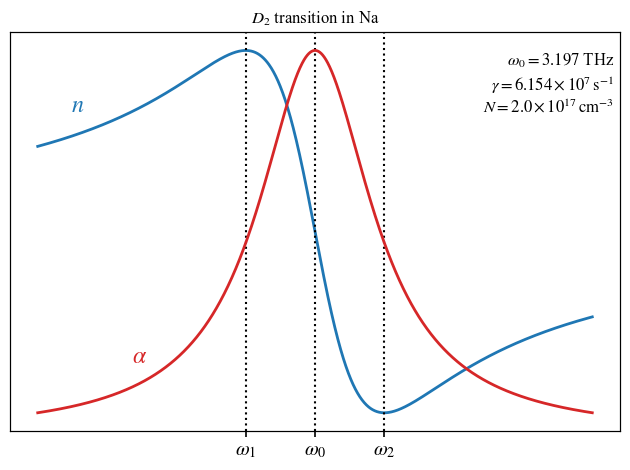

In [80]:
ax = plt.gca()
ax.plot(omega_nat, n_nat, color='tab:blue', lw=2)

ax2 = ax.twinx()
ax2.plot(omega_nat, alpha_nat, color='tab:red', lw=2)

ax.axvline(omega02, color='k', ls=':')

omega_02_1 = omega_nat[np.argmax(n_nat)]
omega_02_2 = omega_nat[np.argmin(n_nat)]

for w in [omega_02_1, omega_02_2]:
    ax.axvline(w, color='k', ls=':')

ax.tick_params(left=False, labelleft=False)
ax2.tick_params(right=False, labelright=False)

ax.set_xticks([omega_02_1, omega02, omega_02_2])
ax.set_xticklabels([r"$\omega_1$", r"$\omega_0$", r"$\omega_2$"], size='x-large')

ax.annotate("$n$", color="tab:blue", xy=(0.1, 0.8), xycoords="axes fraction", 
            fontsize="xx-large")

ax.annotate(r"$\alpha$", color="tab:red", xy=(0.2, 0.17), xycoords="axes fraction", 
            fontsize="xx-large")

string = rf"$\omega_0 = {omega02 / 1e15:.3f}$ THz"
string += "\n"
string += rf"$\gamma = {gamma2_nat / 1e7:.3f}\times 10^7\,\mathrm{{s}}^{{-1}}$"
string += "\n"
string += rf"$N = {N / 1e17:.1f}\times 10^{{17}}\,\mathrm{{cm}}^{{-3}}$"

ax.annotate(string, xy=(0.99, 0.95), ha='right', va='top', xycoords="axes fraction", 
            fontsize="large")

plt.title("$D_2$ transition in Na")
plt.tight_layout()
plt.savefig("anomalous_dispersion.png", dpi=200, transparent=True)

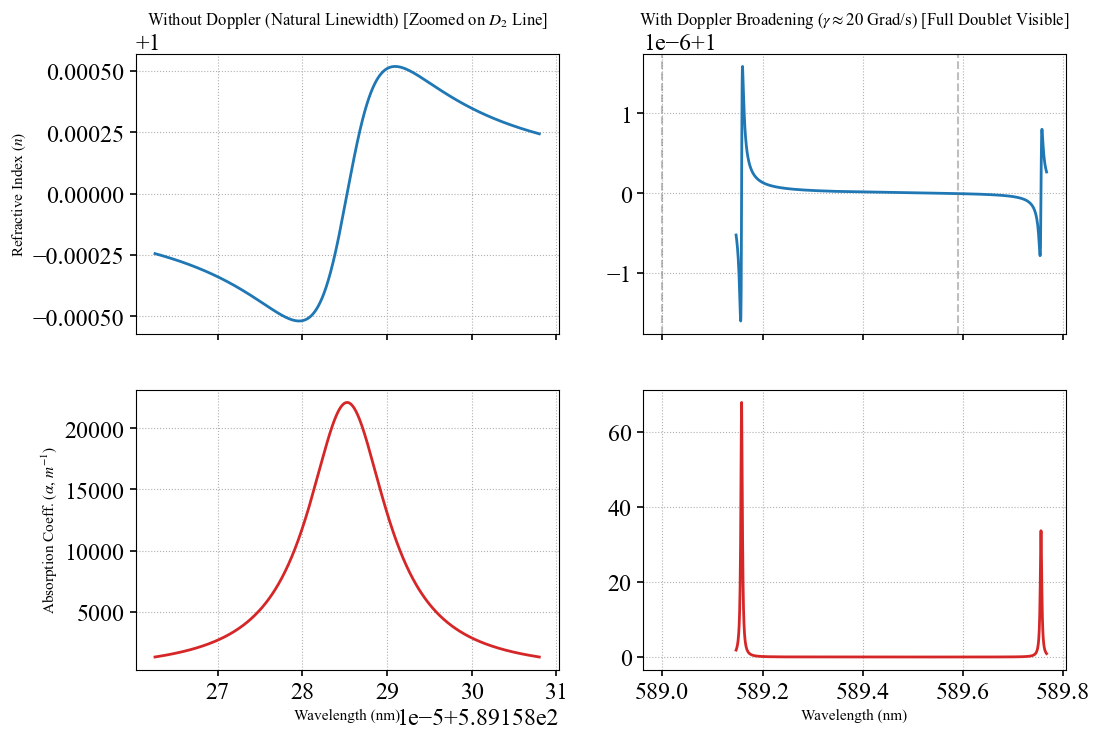

In [77]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8), sharex='col')

axs[0, 0].plot(wave_nat, n_nat, color='tab:blue', lw=2)
axs[0, 0].set_ylabel("Refractive Index ($n$)", fontsize=11)
axs[0, 0].grid(True, linestyle=':')
axs[0, 0].set_title("Without Doppler (Natural Linewidth) [Zoomed on $D_2$ Line]", fontsize=12)

axs[1, 0].plot(wave_nat, alpha_nat, color='tab:red', lw=2)
axs[1, 0].set_xlabel("Wavelength (nm)", fontsize=11)
axs[1, 0].set_ylabel(r"Absorption Coeff. ($\alpha$, $m^{-1}$)", fontsize=11)
axs[1, 0].grid(True, linestyle=':')

axs[0, 1].plot(wave_dop, n_dop, color='tab:blue', lw=2)
axs[0, 1].set_title(r"With Doppler Broadening ($\gamma \approx 20$ Grad/s) [Full Doublet Visible]", fontsize=12)
axs[0, 1].grid(True, linestyle=':')

axs[1, 1].plot(wave_dop, alpha_dop, color='tab:red', lw=2)
axs[1, 1].set_xlabel("Wavelength (nm)", fontsize=11)
axs[1, 1].grid(True, linestyle=':')

axs[0, 1].axvline(589.59, color='gray', linestyle='--', alpha=0.5) # approx D1 position
axs[0, 1].axvline(589.00, color='gray', linestyle='--', alpha=0.5) # approx D2 position
#axs[0, 1].text(589.65, np.max(n_dop)*0.99, '$D_1$', color='gray', fontsize=10)
#axs[0, 1].text(589.05, np.max(n_dop)*0.99, '$D_2$', color='gray', fontsize=10)